In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import plotly.graph_objects as go

In [2]:
#### This code frame uses widgets in search of the grid for hyperbloid formfinding

In [3]:
############ customization
length = 24
width = 24
n1 = 9
n2 = 7
judge = 0
ratio = 0
Initial_r = 1

In [4]:
## grid generation
def generate_rectangular_grid(length, width, n1, n2=2, judge=0, z=0, height=0, d=0, Ratio = ratio, Initial_r = Initial_r):
    
    ratios = [1.0] * n1  

    mid_index = n1 // 2 

    for i in range(mid_index, n1):
        decay_factor = Ratio ** (i - mid_index)  
        ratios[i] *= (Initial_r + d * decay_factor)  
        ratios[n1 - 1 - i] *= (Initial_r + d * decay_factor)  

    total_ratio = sum(ratios)
#     print(ratios)
    normalized_ratios = [r / total_ratio for r in ratios]
#     print(normalized_ratios)
    x_points = [0.0] * (n1 + 1)  
    for i in range(1, n1 + 1):
        x_points[i] = x_points[i - 1] + normalized_ratios[i - 1] * length

    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for x in x_points:
        for y in y_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

In [5]:
 def interactive_plot(d):
    grid_points = generate_rectangular_grid(length, width, n1, n2, judge, d=d)
    plot_grid(grid_points, length, width)

d_slider = widgets.FloatSlider(value=0.0, min=0.0, max=2.0, step=0.05, description='Offset d:')
widgets.interact(interactive_plot, d=d_slider)

interactive(children=(FloatSlider(value=0.0, description='Offset d:', max=2.0, step=0.05), Output()), _dom_cla…

<function __main__.interactive_plot(d)>

In [6]:
grid_points = generate_rectangular_grid(length, width, n1, n2, judge, d=d_slider.value)
connectivity = generate_connectivity_matrix(grid_points)
print(d_slider.value)
print(len(grid_points))
print(len(connectivity))

0.0
80
142


In [7]:
############# Problem context
n_dof_per_node = 6  # Degrees of freedom per node
total_dof = n_dof_per_node * len(grid_points)
grid_points = torch.tensor(grid_points)
########## Surrounding fixed
x_max = grid_points[:, 0].max()
x_min = grid_points[:, 0].min()
y_max = grid_points[:, 1].max()
y_min = grid_points[:, 1].min()
Fixed_nodes = torch.where(
#     (grid_points[:, 0] == x_max) |  # x = x_max
#     (grid_points[:, 0] == x_min) |  # x = x_min
    (grid_points[:, 1] == y_max) |  # y = y_max
    (grid_points[:, 1] == y_min)    # y = y_min
)[0]

Fixed_nodes += 1
Free_nodes = []
# n_elements = len(connectivity)
n_nodes = len(grid_points)
for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)

F = torch.zeros(total_dof, dtype=torch.float32)
f_n = Free_nodes
f_type = [2] * len(Free_nodes)  # The force type
F_value = torch.tensor([-50.0] * len(Free_nodes)) * 100 # The force value/direction

r = 1 / torch.max(F_value)

F_sign = torch.sign(F_value)
for idx, i in enumerate(f_n):
    F[6 * (i - 1) + f_type[idx]] = F_value[idx]  # unit: KN / KN*m

####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])

print(len(Free_nodes))

idx_Fixed = torch.tensor(Fixed_nodes) - 1
idx_Free = torch.tensor(Free_nodes) - 1 

60


/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_2674/2280263008.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  idx_Fixed = torch.tensor(Fixed_nodes) - 1


In [8]:

def find_connectivity_indices(grid_points, connectivity, free_nodes):
    
    
    grid_points = torch.tensor(grid_points, dtype=torch.float32)
    
    connectivity = torch.tensor(connectivity, dtype=torch.long)
    
    free_nodes = torch.tensor(free_nodes, dtype=torch.long)
    
    result_indices_x = []  
    result_indices_y = []  
    
    prev_x_list = []  
    prev_y_list = []  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1] 
        x = node_coord[0]

        if x in prev_x_list:
            x_index = prev_x_list.index(x)
        else:
            result_indices_x.append([])
            prev_x_list.append(x)
            x_index = len(prev_x_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        candidate_indices = torch.where(mask)[0] # indexing connectivity
        
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]

            if coord1[0] == coord2[0] and coord1[0] == x:
                result_indices_x[x_index].append(idx.item())  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1]  
        y = node_coord[1]
        
        if y in prev_y_list:
            y_index = prev_y_list.index(y)
        else:
            result_indices_y.append([])
            prev_y_list.append(y)
            y_index = len(prev_y_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        print(mask)
        candidate_indices = torch.where(mask)[0]
        print(candidate_indices)
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]
            
            if coord1[1] == coord2[1] and coord1[1] == y:
                result_indices_y[y_index].append(idx.item()) 

    print(" x unorganized：", result_indices_x)
    print(" y unorganized：", result_indices_y)
    
 ##### Do the clean-up

    max_len_x = max(len(indices) for indices in result_indices_x) if result_indices_x else 0
    max_len_y = max(len(indices) for indices in result_indices_y) if result_indices_y else 0
    
    
    for indices in result_indices_x:
        indices += [-1] * (max_len_x - len(indices))
    for indices in result_indices_y:
        indices += [-1] * (max_len_y - len(indices))
    
    
    result_x = torch.tensor(result_indices_x, dtype=torch.long)
    result_y = torch.tensor(result_indices_y, dtype=torch.long)
    result_x = torch.unique(result_x, dim=1)
    result_y = torch.unique(result_y, dim=1)
    return result_x, result_y

idx_X, idx_Y = find_connectivity_indices(grid_points, connectivity, Free_nodes)
print("x indices：")
print(idx_X,)
print("y indices：")
print(idx_Y)

tensor([ True,  True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, 

/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_2674/270520761.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  grid_points = torch.tensor(grid_points, dtype=torch.float32)


In [9]:
####### Symetry reshaper -- quires even numbers of indices
len_y = idx_Y.size(0)
half_y = len_y // 2
len_x = idx_X.size(0)
half_x = len_x // 2

y_upper = idx_Y[:half_y]  
y_lower = idx_Y[half_y:] 
y_lower = torch.flip(y_lower, dims=[0])
x_upper = idx_X[:half_x]  
x_lower = idx_X[half_x:]  
x_lower = torch.flip(x_lower, dims=[0])


idx_Y = torch.cat((y_upper, y_lower), dim=1)
idx_X = torch.cat((x_upper, x_lower), dim=1)   

print("Recomposed Y mat:")
print(idx_Y)
print("Recomposed X mat:")
print(idx_X)

Recomposed Y mat:
tensor([[124, 125, 126, 127, 128, 129, 130, 131, 132,  79,  80,  81,  82,  83,
          84,  85,  86,  87],
        [115, 116, 117, 118, 119, 120, 121, 122, 123,  88,  89,  90,  91,  92,
          93,  94,  95,  96],
        [106, 107, 108, 109, 110, 111, 112, 113, 114,  97,  98,  99, 100, 101,
         102, 103, 104, 105]])
Recomposed X mat:
tensor([[ 0,  1,  2,  3,  4,  5,  6, 63, 64, 65, 66, 67, 68, 69],
        [ 7,  8,  9, 10, 11, 12, 13, 56, 57, 58, 59, 60, 61, 62],
        [14, 15, 16, 17, 18, 19, 20, 49, 50, 51, 52, 53, 54, 55],
        [21, 22, 23, 24, 25, 26, 27, 42, 43, 44, 45, 46, 47, 48],
        [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]])


In [10]:
### This part is for obtaining the Target geometry:
# ###############################
# ######### THis is for double curvatures

# def generate_rectangular_grid_db(length, width, n1, X_ref = 0, n2=2, judge=0, z=0, Max_height=12, Min_height=6.12, Ratio = ratio, Initial_r = Initial_r, d = d_slider.value):
   
#     print(X_ref)
    
#     ratios = [1.0] * n1  

#     mid_index = n1 // 2 

#     for i in range(mid_index, n1):
#         decay_factor = Ratio ** (i - mid_index)  
#         ratios[i] *= (Initial_r + d * decay_factor)  
#         ratios[n1 - 1 - i] *= (Initial_r + d * decay_factor)  

#     total_ratio = sum(ratios)
# #     print(ratios)
#     normalized_ratios = [r / total_ratio for r in ratios]
# #     print(normalized_ratios)
#     x_points = [0.0] * (n1 + 1)  
#     for i in range(1, n1 + 1):
#         x_points[i] = x_points[i - 1] + normalized_ratios[i - 1] * length

#     y_points = [j * (width / n2) for j in range(n2, -1, -1)]
    
#     x_values = [X_ref, length/2, length - X_ref]
    
#     z_values = [Max_height, Min_height ,Max_height]
    
#     coefficients = np.polyfit(x_values, z_values, 2)
#     a, b, c = coefficients
    
#     x_points = torch.tensor(x_points)
    
#     height = a * x_points**2 + b * x_points + c

#     grid_points = []
#     for y in y_points:
#         for idx, x in enumerate(x_points):
#             if y == width / 2:
#                 grid_points.append([x, y, height[idx]])
#             else:
#                 grid_points.append([x, y, z])

#     if judge == 1:
#         corners = [
#             [x_points[0], y_points[0], z],
#             [x_points[0], y_points[-1], z],
#             [x_points[-1], y_points[0], z],
#             [x_points[-1], y_points[-1], z]
#         ]
#         grid_points = [point for point in grid_points if point not in corners]

#     return grid_points

# def add_points(node_coords_db, n):
#     node_coords = node_coords_db.numpy()
#     x_values = np.unique(node_coords[:, 0])
#     new_coords = []

#     for x in x_values:
#         points_on_line = node_coords[node_coords[:, 0] == x]
#         y_values = points_on_line[:, 1]
#         z_values = points_on_line[:, 2]
#         coefficients = np.polyfit(y_values, z_values, 2)
#         a, b, c = coefficients
#         y_new = np.linspace(max(y_values), min(y_values), n + 2)
#         z_new = a * y_new**2 + b * y_new + c

#         for y, z in zip(y_new, z_new):
#             new_coords.append([x, y, z])

#     new_coords = torch.tensor(new_coords, dtype=torch.float32)
#     return new_coords

# def generate_connectivity_matrix(new_coords):

#     indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

#     connectivity = []


#     x_values = sorted(set(point[0] for point in new_coords))
#     for x in x_values:

#         points_on_line = [point for point in new_coords if point[0] == x]
#         points_on_line.sort(key=lambda p: p[1], reverse=True) 


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])


#     y_values = sorted(set(point[1] for point in new_coords))
#     for y in y_values:
       
#         points_on_line = [point for point in new_coords if point[1] == y]
#         points_on_line.sort(key=lambda p: p[0])  


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])

#     return connectivity


# def plot_grid(grid_points, length, width):
#     x = [point[0] for point in grid_points]
#     y = [point[1] for point in grid_points]
#     z = [point[2] for point in grid_points]

#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.legend()
#     plt.show()


# def plot_points(points):
#     if isinstance(points, list):
#         points = torch.tensor(points, dtype=torch.float32)
#     points = points.numpy()
#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     x = points[:, 0]
#     y = points[:, 1]
#     z = points[:, 2]
#     ax.scatter(x, y, z, c='b', marker='o')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.set_title('Generated Points on Shell Beam')
#     plt.show()



In [11]:
#  def obj_plot(X_ref):
#     grid_points_db = generate_rectangular_grid_db(length, width, n1, X_ref=X_ref)
#     node_coords_db = torch.tensor(grid_points_db)
#     new_coords_db = add_points(node_coords_db, n_)
#     new_coords_db = torch.tensor(new_coords_db, dtype=torch.float32)
#     plot_grid(grid_points_db, length, width)
#     plot_points(new_coords_db)

# x_slider = widgets.FloatSlider(value=0.0, min=0.0, max=12.0, step=4.0, description='Offset X_ref:')
# widgets.interact(obj_plot, X_ref=x_slider)

In [12]:
# grid_points_db = generate_rectangular_grid_db(length, width, n1, X_ref=x_slider.value)
# node_coords_db = torch.tensor(grid_points_db)
# new_coords_db = add_points(node_coords_db, n_)
# print(x_slider.value)
# print(new_coords_db)
# print(new_coords_db.shape)

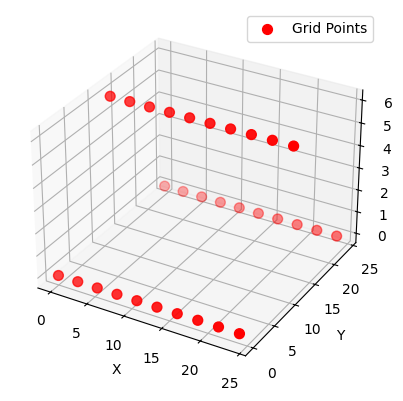

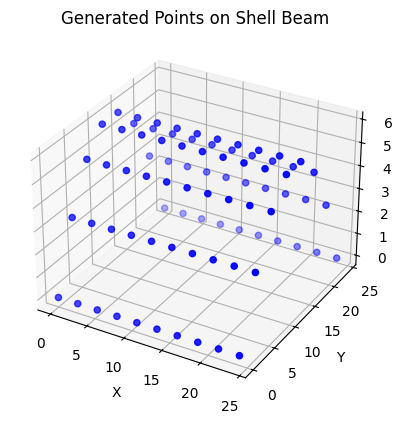

[[0.0, 24.0, 0], [2.6666666666666665, 24.0, 0], [5.333333333333333, 24.0, 0], [8.0, 24.0, 0], [10.666666666666666, 24.0, 0], [13.333333333333332, 24.0, 0], [16.0, 24.0, 0], [18.666666666666664, 24.0, 0], [21.333333333333332, 24.0, 0], [24.0, 24.0, 0], [0.0, 12.0, 6], [2.6666666666666665, 12.0, 6], [5.333333333333333, 12.0, 6], [8.0, 12.0, 6], [10.666666666666666, 12.0, 6], [13.333333333333332, 12.0, 6], [16.0, 12.0, 6], [18.666666666666664, 12.0, 6], [21.333333333333332, 12.0, 6], [24.0, 12.0, 6], [0.0, 0.0, 0], [2.6666666666666665, 0.0, 0], [5.333333333333333, 0.0, 0], [8.0, 0.0, 0], [10.666666666666666, 0.0, 0], [13.333333333333332, 0.0, 0], [16.0, 0.0, 0], [18.666666666666664, 0.0, 0], [21.333333333333332, 0.0, 0], [24.0, 0.0, 0]]


In [13]:
######### THis is for single curvatures
import torch
import numpy as np
import matplotlib.pyplot as plt

n_1 = 9
n_2 = 2
n = 6 

def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, h=6):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for y in y_points:
        for x in x_points:
            if y == width / 2:
                grid_points.append([x, y, h])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def add_points(node_coords_sg, n):
    node_coords = node_coords_sg.numpy()
    x_values = np.unique(node_coords[:, 0])
    new_coords = []

    for x in x_values:
        points_on_line = node_coords[node_coords[:, 0] == x]
        y_values = points_on_line[:, 1]
        z_values = points_on_line[:, 2]
        coefficients = np.polyfit(y_values, z_values, 2)
        a, b, c = coefficients
        y_new = np.linspace(max(y_values), min(y_values), n + 2)
        z_new = a * y_new**2 + b * y_new + c

        for y, z in zip(y_new, z_new):
            new_coords.append([x, y, z])

    new_coords = torch.tensor(new_coords, dtype=torch.float32)
    return new_coords

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points_sg = generate_rectangular_grid_sg(length, width, n_1, n_2, judge)

node_coords_sg = torch.tensor(grid_points_sg)

new_coords_sg = add_points(node_coords_sg, n)

new_coords_sg = new_coords_sg.tolist()

connectivity_sg = generate_connectivity_matrix(new_coords_sg)

new_coords_sg = torch.tensor(new_coords_sg, dtype=torch.float32)
############## plotting

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()


def plot_points(points):
    if isinstance(points, list):
        points = torch.tensor(points, dtype=torch.float32)
    points = points.numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    ax.scatter(x, y, z, c='b', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Generated Points on Shell Beam')
    plt.show()

    

plot_grid(grid_points_sg,length,width)
plot_points(new_coords_sg)

print(grid_points_sg)

In [14]:
#######
# Redefine the OBJ:
Obj_coords = new_coords_sg[idx_Free][:, 2]
print(Obj_coords)
print(idx_Free)

tensor([2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776,
        5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388,
        2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776,
        5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388,
        2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776,
        5.8776, 4.8980, 2.9388, 2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388,
        2.9388, 4.8980, 5.8776, 5.8776, 4.8980, 2.9388])
tensor([ 1,  2,  3,  4,  5,  6,  9, 10, 11, 12, 13, 14, 17, 18, 19, 20, 21, 22,
        25, 26, 27, 28, 29, 30, 33, 34, 35, 36, 37, 38, 41, 42, 43, 44, 45, 46,
        49, 50, 51, 52, 53, 54, 57, 58, 59, 60, 61, 62, 65, 66, 67, 68, 69, 70,
        73, 74, 75, 76, 77, 78])


In [15]:
####### Gradient descent
step = 0.001
epochs = 1500

In [ ]:
########## Differentiable FDM

# px = torch.zeros(len(f_n), 1, dtype=torch.float32)
px = torch.zeros(len(f_n), 1, dtype=torch.float32)
py = torch.zeros(len(f_n), 1, dtype=torch.float32)
pz = torch.zeros(len(f_n), 1, dtype=torch.float32)

for i, node in enumerate(f_n):
    if f_type[i] == 0:
        px[i] = F_value[i]
    elif f_type[i] == 1:
        py[i] = F_value[i]
    elif f_type[i] == 2:
        pz[i] = F_value[i]


## Obtaining Matrix D
# Assembly the nodal-branch matrix:
n_elements = len(connectivity)
idx_CF = idx_Fixed
idx_CN = idx_Free
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1
CF = C[:, idx_CF]
CN = C[:, idx_CN]


# Assembly D
def FDM (Q, C=C, CN=CN, CF=CF, px=px, py=py, pz=pz,Fixed_nodes=Fixed_nodes, Free_nodes=Free_nodes,node_coords=grid_points) :
    Dn = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CN))
    DF = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CF))
    ## Coordinates solution
    # separate the coordinates:
    fixed_idces = [node - 1 for node in Fixed_nodes]
    xF = node_coords[fixed_idces, 0].unsqueeze(1)
    yF = node_coords[fixed_idces, 1].unsqueeze(1)
    zF = node_coords[fixed_idces, 2].unsqueeze(1)
    xN = torch.matmul(torch.inverse(Dn), (px - torch.matmul(DF, xF)))
    yN = torch.matmul(torch.inverse(Dn), (py - torch.matmul(DF, yF)))
    zN = torch.matmul(torch.inverse(Dn), (pz - torch.matmul(DF, zF)))
    ## Coordinates renewal: 
    new_node_coords = node_coords.clone()
    for idx, node in enumerate(Free_nodes):
        node_idx = node - 1
        new_node_coords[node_idx, 0] = xN[idx]
        new_node_coords[node_idx, 1] = yN[idx]
        new_node_coords[node_idx, 2] = zN[idx]
#     print(new_node_coords[:,0])
    return new_node_coords





####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])


# ### Defining the OBJ:
# Obj_coords = torch.full((len(Free_nodes),), 12)



def Loss(Free_nodes, new_node_coords, Obj_coords):
    n_free_nodes = len(Free_nodes)
    Free_nodes = torch.tensor(Free_nodes)
    y_pred = new_node_coords[(Free_nodes - 1), 2]  
    y_true = Obj_coords 
    error = torch.abs(y_true - y_pred)
    loss = torch.mean(error)
    return loss


# Optimized Variables
## initial variables
n_elem = len(idx_X) + len(idx_Y)
q = torch.rand(n_elem, requires_grad=True)
print(n_elem)
## Optimization
torch.autograd.set_detect_anomaly(True)
optimizer = optim.Adam([q], lr=step)
# Loop start
Loss_his = []
for iteration in range(epochs + 1):
    print(iteration)
    # Forwards
    q_vec = torch.zeros(n_elements, requires_grad=True).clone()
    for i in range(len(idx_X)):
        q_vec[idx_X[i,:]] = q[i] 
    for j in range(len(idx_Y)):
        q_vec[idx_Y[j,:]] = q[j+len(idx_X)]  
    Q = torch.diag(q_vec) * 1 / r  # scaling
    new_node_coords = FDM(Q)
    # loss
    Loss_value = Loss(Free_nodes, new_node_coords, Obj_coords)
    Loss_his.append(Loss_value.item())
    # Backwards
    optimizer.zero_grad()
    # print(q.grad)
    Loss_value.backward(retain_graph=True)

    # Grad
    gradients = q.grad
    # print(gradients)
    frob_norm = torch.norm(gradients)
    
    # Step
    optimizer.step()
#   print(gradients)
# #     mean_error = torch.mean(error)
#     for i in range(len(q)):
#         if error[i] > 2 * mean_error:
#             q[i].data -= 5 * step * q.grad[i] 
#         else:
#             q[i].data -= step * q.grad[i]
    # print(new_node_coords)
    # print iteration
    if iteration % 5 == 0:
        print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")
print("Optimization completed.")
print(q)
print(new_node_coords)



8
0
Iteration 0: Normalized Gradient = 5.529385566711426, Adaptive learning rate = 0.001
1
2
3
4
5
Iteration 5: Normalized Gradient = 5.435366153717041, Adaptive learning rate = 0.001
6
7
8
9
10
Iteration 10: Normalized Gradient = 5.344037055969238, Adaptive learning rate = 0.001
11
12
13
14
15
Iteration 15: Normalized Gradient = 5.255399703979492, Adaptive learning rate = 0.001
16
17
18
19
20
Iteration 20: Normalized Gradient = 5.169461250305176, Adaptive learning rate = 0.001
21
22
23
24
25
Iteration 25: Normalized Gradient = 5.086179256439209, Adaptive learning rate = 0.001
26
27
28
29
30
Iteration 30: Normalized Gradient = 5.005499362945557, Adaptive learning rate = 0.001
31
32
33
34
35
Iteration 35: Normalized Gradient = 4.9273552894592285, Adaptive learning rate = 0.001
36
37
38
39
40
Iteration 40: Normalized Gradient = 4.851654529571533, Adaptive learning rate = 0.001
41
42
43
44
45
Iteration 45: Normalized Gradient = 4.778323173522949, Adaptive learning rate = 0.001
46
47
48
49

In [ ]:
#############################################################################################################
x_orig = grid_points[:, 0].detach().numpy()
y_orig = grid_points[:, 1].detach().numpy()
z_orig = grid_points[:, 2].detach().numpy()

x_def = new_node_coords[:, 0].detach().numpy()
y_def = new_node_coords[:, 1].detach().numpy()
z_def = new_node_coords[:, 2].detach().numpy()

fig = go.Figure()

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Original Geometry'
    ))

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FDM Solution'
    ))

# for node in Free_nodes:
#     fig.add_trace(go.Scatter3d(
#         x=[x_def[node-1]],
#         y=[y_def[node-1]],
#         z=[z_def[node-1]],
#         mode='markers+text',
#         marker=dict(size=5, color='green'),
#         text=[f'Node {node}'],
#         textposition='top center',
#         name=f'Free Node {node}'
#     ))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Original vs. FDM',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.write_html("Go_figure_Widgets.html")

# Plot loss history
plt.figure()
plt.plot(range(epochs + 1), Loss_his, label='Loss History', color='blue', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Optimization Loss vs. Iterations')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(Obj_coords)

In [ ]:
##### TNA reverse-q finding

x = new_coords_db[:, 0]
y = new_coords_db[:, 1]
z = new_coords_db[:, 2]

n_elements = len(connectivity)
n_nodes = len(new_coords_db)
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1

# 分解连接矩阵
CF = C[:, idx_Free]  # 自由节点部分
CN = C[:, idx_Fixed]  # 固定节点部分

# 提取自由节点和固定节点的 z 坐标
z_F = z[idx_Free]  # 自由节点的 z 坐标
z_N = z[idx_Fixed]  # 固定节点的 z 坐标

# 构建力平衡方程
d = CF @ z_F + CN @ z_N  # d = C_F z_F + C_N z_N
A = CF.T @ torch.diag(d)  # A = C_F^T diag(d)

print(A.shape)
Free_nodes = torch.tensor(Free_nodes)
idx = (Free_nodes - 1)*6 + 2
F_z = F[idx]
print(idx)
print(F_z.shape) 
# 求解力密度 q
q_TNA = torch.linalg.lstsq(A, F_z).solution

print("力密度 q:", q_TNA)
print(len(q))

In [ ]:
## FDM Validation

Q_T = torch.diag(q_TNA)  
new_node_coords = FDM(Q_T)
print(new_node_coords)
# 绘图
x_orig = grid_points[:, 0].detach().numpy()
y_orig = grid_points[:, 1].detach().numpy()
z_orig = grid_points[:, 2].detach().numpy()

x_def = grid_points[:, 0].detach().numpy()
y_def = grid_points[:, 1].detach().numpy()
z_def = new_node_coords[:, 2].detach().numpy()

fig = go.Figure()

# 绘制原始网格
for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Original Geometry'
    ))

# 绘制 FDM 找形后的网格
for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FDM Solution'
    ))

# 标注自由节点
for node in idx_Free:
    fig.add_trace(go.Scatter3d(
        x=[x_def[node-1]],
        y=[y_def[node-1]],
        z=[z_def[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='green'),
        text=[f'Node {node}'],
        textposition='top center',
        name=f'Free Node {node}'
    ))

# 更新布局
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Original vs. FDM',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# 保存为 HTML 文件
fig.write_html("Vali_Widgets.html")
print('complete')

In [ ]:

#######################################
# ### For single curvature
# def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, height=6):
#     x_points = [i * (length / n1) for i in range(n1 + 1)]
#     y_points = [j * (width / n2) for j in range(n2, -1, -1)]

#     grid_points = []
#     for y in y_points:
#         for x in x_points:
#             if y == width / 2:
#                 grid_points.append([x, y, height])
#             else:
#                 grid_points.append([x, y, z])

#     if judge == 1:
#         corners = [
#             [x_points[0], y_points[0], z],
#             [x_points[0], y_points[-1], z],
#             [x_points[-1], y_points[0], z],
#             [x_points[-1], y_points[-1], z]
#         ]
#         grid_points = [point for point in grid_points if point not in corners]

#     return grid_points

# def add_points(node_coords_sg, n):
#     node_coords = node_coords_sg.numpy()
#     x_values = np.unique(node_coords[:, 0])
#     new_coords = []

#     for x in x_values:
#         points_on_line = node_coords[node_coords[:, 0] == x]
#         y_values = points_on_line[:, 1]
#         z_values = points_on_line[:, 2]
#         coefficients = np.polyfit(y_values, z_values, 2)
#         a, b, c = coefficients
#         y_new = np.linspace(max(y_values), min(y_values), n + 2)
#         z_new = a * y_new**2 + b * y_new + c

#         for y, z in zip(y_new, z_new):
#             new_coords.append([x, y, z])

#     new_coords = torch.tensor(new_coords, dtype=torch.float32)
#     return new_coords

# def generate_connectivity_matrix(new_coords):

#     indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

#     connectivity = []


#     x_values = sorted(set(point[0] for point in new_coords))
#     for x in x_values:

#         points_on_line = [point for point in new_coords if point[0] == x]
#         points_on_line.sort(key=lambda p: p[1], reverse=True) 


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])


#     y_values = sorted(set(point[1] for point in new_coords))
#     for y in y_values:
       
#         points_on_line = [point for point in new_coords if point[1] == y]
#         points_on_line.sort(key=lambda p: p[0])  


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])

#     return connectivity

# grid_points_sg = generate_rectangular_grid_sg(length, width, n1, n2, judge)

# node_coords_sg = torch.tensor(grid_points_sg)

# new_coords_sg = add_points(node_coords_sg, n)

# new_coords_sg = new_coords_sg.tolist()

# connectivity_sg = generate_connectivity_matrix(new_coords_sg)

# new_coords_sg = torch.tensor(new_coords_sg, dtype=torch.float32)
# ############## plotting

# def plot_grid(grid_points, length, width):
#     x = [point[0] for point in grid_points]
#     y = [point[1] for point in grid_points]
#     z = [point[2] for point in grid_points]

#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.legend()
#     plt.show()


# def plot_points(points):
#     if isinstance(points, list):
#         points = torch.tensor(points, dtype=torch.float32)
#     points = points.numpy()
#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     x = points[:, 0]
#     y = points[:, 1]
#     z = points[:, 2]
#     ax.scatter(x, y, z, c='b', marker='o')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.set_title('Generated Points on Shell Beam')
#     plt.show()


# plot_grid(grid_points_sg,length,width)
# plot_points(new_coords_sg)
